# Banka Vadeli Mevduat Aboneliği Tahmin

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTdWJ-pTs7uWb84nAav9ZMKc2849Q3Hi7i9ww&s"> 

Bu projede, bankanın doğrudan pazarlama kampanyalarına ait müşteri verileri kullanılarak, müşterilerin vadeli mevduat hesabı açıp açmayacağını tahmin eden bir makine öğrenmesi modeli geliştirilmiştir. Çalışmada müşterilerin demografik bilgileri, finansal durumları ve geçmiş kampanya etkileşimleri analiz edilerek problem bir ikili sınıflandırma problemi olarak ele alınmıştır. Veri ön işleme ve modelleme adımlarının ardından farklı algoritmalar karşılaştırılmış ve performansları çeşitli değerlendirme metrikleri ile analiz edilmiştir. Elde edilen sonuçlar, bankaların pazarlama süreçlerini daha verimli yönetmesine ve doğru müşterileri hedeflemesine katkı sağlamayı amaçlamaktadır.

### Sütun Açıklamaları

**age**
→ Müşterinin yaşını gösterir.

**job**
→ Müşterinin meslek grubunu belirtir.

**marital**
→ Müşterinin medeni durumunu (married, single, divorced vb.) gösterir.

**education**
→ Müşterinin eğitim seviyesini belirtir.

**default**
→ Müşterinin kredi temerrüdü (borcunu ödeyememe) geçmişi olup olmadığını gösterir.

**balance**
→ Müşterinin banka hesabındaki yıllık ortalama bakiye miktarını ifade eder.

**housing**
→ Müşterinin konut kredisi olup olmadığını belirtir.

**loan**
→ Müşterinin bireysel kredi kullanıp kullanmadığını gösterir.

**contact**
→ Bankanın müşteriyle hangi iletişim kanalı üzerinden iletişime geçtiğini gösterir (cellular, telephone vb.).

**day**
→ Son iletişimin ayın kaçıncı günü gerçekleştiğini gösterir.

**month**
→ Son iletişimin hangi ayda yapıldığını belirtir.

**duration**
→ Müşteriyle yapılan son telefon görüşmesinin süresini saniye cinsinden gösterir.

**campaign**
→ Mevcut kampanya sürecinde müşteriyle kaç kez iletişime geçildiğini belirtir.

**pdays**
→ Müşteriyle önceki kampanyadan sonra kaç gün geçtiğini gösterir (-1 ise daha önce iletişim kurulmamıştır).

**previous**
→ Önceki kampanyalarda müşteriyle kaç kez iletişim kurulduğunu belirtir.

**poutcome**
→ Önceki pazarlama kampanyasının sonucunu (success, failure, unknown vb.) gösterir.

**y**
→ Müşterinin vadeli mevduat hesabı açıp açmadığını (yes/no) ifade eden hedef değişkendir.

### Veri seti kaynağı

https://www.kaggle.com/datasets/sude41/abonemusteri

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


/kaggle/input/abonemusteri/bank-full.csv


In [2]:

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier


from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score


import warnings
warnings.filterwarnings("ignore")


In [3]:
import pandas as pd

path = "/kaggle/input/abonemusteri/bank-full.csv"

df = pd.read_csv(path, sep=";")

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape


(45211, 17)

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
df["y"].value_counts()


y
no     39922
yes     5289
Name: count, dtype: int64

In [9]:
df.corr(numeric_only=True)

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


In [10]:
df["y"] = df["y"].map({"no": 0, "yes": 1})


In [11]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


In [12]:
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(exclude="object").columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)


Categorical: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')
Numerical: Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'y'],
      dtype='object')


In [13]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [14]:
df_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  45211 non-null  int64
 1   balance              45211 non-null  int64
 2   day                  45211 non-null  int64
 3   duration             45211 non-null  int64
 4   campaign             45211 non-null  int64
 5   pdays                45211 non-null  int64
 6   previous             45211 non-null  int64
 7   y                    45211 non-null  int64
 8   job_blue-collar      45211 non-null  bool 
 9   job_entrepreneur     45211 non-null  bool 
 10  job_housemaid        45211 non-null  bool 
 11  job_management       45211 non-null  bool 
 12  job_retired          45211 non-null  bool 
 13  job_self-employed    45211 non-null  bool 
 14  job_services         45211 non-null  bool 
 15  job_student          45211 non-null  bool 
 16  job_technician       4

In [15]:
x = df_encoded.drop("y", axis=1)
y = df_encoded["y"]


In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)


In [17]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

g = GaussianNB()
model_gnb = g.fit(x_train, y_train)
tahmin_gnb = model_gnb.predict(x_test)

accuracy_score(y_test, tahmin_gnb)


0.8577905562313392

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
model_lr = lr.fit(x_train, y_train)
tahmin_lr = model_lr.predict(x_test)

accuracy_score(y_test, tahmin_lr)


0.8988167643481145

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)
model_dt = dt.fit(x_train, y_train)
tahmin_dt = model_dt.predict(x_test)

accuracy_score(y_test, tahmin_dt)


0.8705075749198274

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
model_knn = knn.fit(x_train, y_train)
tahmin_knn = model_knn.predict(x_test)

accuracy_score(y_test, tahmin_knn)


0.8754837996240186

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=300, random_state=42)
model_rf = rf.fit(x_train, y_train)
tahmin_rf = model_rf.predict(x_test)

accuracy_score(y_test, tahmin_rf)


0.9052305650779608

In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb = GradientBoostingClassifier(random_state=42)
model_gb = gb.fit(x_train, y_train)
tahmin_gb = model_gb.predict(x_test)

accuracy_score(y_test, tahmin_gb)


0.9035718235098972

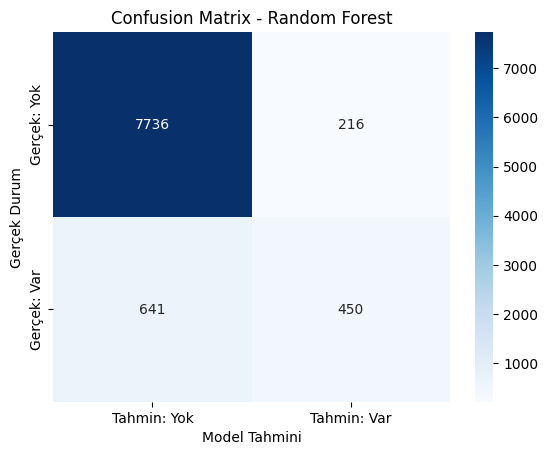

In [23]:
cm_rf = confusion_matrix(y_test, tahmin_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin: Yok', 'Tahmin: Var'],
            yticklabels=['Gerçek: Yok', 'Gerçek: Var'])

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Model Tahmini")
plt.ylabel("Gerçek Durum")
plt.show()


### Önemli Not 

Bu veri setinde:

“no” sayısı çok fazla

“yes” sayısı az (class imbalance var)

Bu yüzden:
 Accuracy tek başına yeterli değil.

Banka açısından daha önemli olan:

Recall (1 sınıfı için)
Yani abone olacak müşterileri kaçırmamak.

In [24]:
print(classification_report(y_test, tahmin_rf))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.68      0.41      0.51      1091

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043



### Toplu bir şekilde görebiliriz model tahmin sonuçlarını

In [25]:
from sklearn.metrics import accuracy_score

print("===== ACCURACY SONUÇLARI =====\n")

print("GaussianNB         :", accuracy_score(y_test, tahmin_gnb))
print("Logistic Regression:", accuracy_score(y_test, tahmin_lr))
print("Decision Tree      :", accuracy_score(y_test, tahmin_dt))
print("Random Forest      :", accuracy_score(y_test, tahmin_rf))
print("Gradient Boosting  :", accuracy_score(y_test, tahmin_gb))
print("KNN                :", accuracy_score(y_test, tahmin_knn))


===== ACCURACY SONUÇLARI =====

GaussianNB         : 0.8577905562313392
Logistic Regression: 0.8988167643481145
Decision Tree      : 0.8705075749198274
Random Forest      : 0.9052305650779608
Gradient Boosting  : 0.9035718235098972
KNN                : 0.8754837996240186


## Sonuç

Bu projede banka müşterilerinin vadeli mevduat hesabı açma durumunu tahmin etmek amacıyla farklı sınıflandırma modelleri uygulanmış ve performansları karşılaştırılmıştır. Elde edilen sonuçlara göre Random Forest ve Gradient Boosting modelleri en yüksek doğruluk oranına ulaşarak en başarılı modeller olmuştur. Logistic Regression ise dengeli performansı ve yorumlanabilir yapısıyla güçlü bir alternatif sunmuştur.

Genel olarak, ağaç tabanlı modellerin bu veri setinde daha iyi sonuç verdiği görülmüş ve pazarlama kampanyalarının daha verimli yürütülmesi için Random Forest veya Gradient Boosting modellerinin tercih edilmesi uygun bulunmuştur.